# Quickstart

This example trains a small `braintrace.nn.MiniGRU` on one fixed sequence. It shows the complete online-learning path: compile the model, differentiate each time step, scan over the sequence, update parameters, and compare loss from clean initial states.

In [1]:
import brainstate
import braintools
import braintrace
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Fixed model initialization and fixed data make the result reproducible.
brainstate.random.seed(7)


class SequenceModel(brainstate.nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = braintrace.nn.MiniGRU(in_size=1, out_size=6)
        self.readout = braintrace.nn.Linear(6, 1)

    def update(self, x):
        return self.readout(self.rnn(x))


model = SequenceModel()
inputs = jnp.linspace(-1.0, 1.0, 12).reshape(12, 1, 1)
targets = 0.7 * inputs + 0.2

# Compile once. inputs[0] is one batched time step with shape (1, 1).
# The compiler reports that the readout is non-temporal because it does not
# feed a recurrent state.
learner = braintrace.compile(
    model,
    braintrace.D_RTRL,
    inputs[0],
    batch_size=1,
)
weights = model.states(brainstate.ParamState)
optimizer = braintools.optim.SGD(lr=0.08)
optimizer.register_trainable_weights(weights)

SGD(
  momentum=0.0,
  nesterov=False,
  param_states=<braintools.optim.UniqueStateManager object at 0x779af84e4050>,
  weight_decay=0.0,
  step_count=OptimState(
    value=ShapedArray(int32[], weak_type=True)
  ),
  param_groups=[
    {
      'params': {
        ('readout', 'weight'): ParamState(
          value={
            'bias': ShapedArray(float32[1]),
            'weight': ShapedArray(float32[6,1])
          }
        ),
        ('rnn', 'W_x', 'weight'): ParamState(
          value={
            'bias': ShapedArray(float32[6], weak_type=True),
            'weight': ShapedArray(float32[1,6])
          }
        ),
        ('rnn', 'W_z', 'weight'): ParamState(
          value={
            'bias': ShapedArray(float32[6], weak_type=True),
            'weight': ShapedArray(float32[7,6])
          }
        )
      },
      'lr': OptimState(
        value=ShapedArray(float32[], weak_type=True)
      ),
      'weight_decay': 0.0
    }
  ],
  param_groups_opt_states=[],
  _schedulers=

In [2]:
def reset_sequence():
    # Hidden states and eligibility traces are independent state systems.
    brainstate.nn.reset_all_states(model, batch_size=1)
    learner.reset_state(batch_size=1)


def evaluate():
    reset_sequence()
    predictions = learner.etrace_evolve(inputs, return_outputs=True)
    return jnp.mean((predictions - targets) ** 2)


def local_loss(x, target):
    prediction = learner(x)
    return jnp.mean((prediction - target) ** 2)


def train_epoch(_):
    reset_sequence()
    # etrace_grad owns the loop, the accumulation and the reduction; local_loss
    # owns the model call. 'mean' divides by the total mask weight -- here T --
    # which is exactly the hand-written `grads / inputs.shape[0]` it replaces.
    grads, step_losses = learner.etrace_grad(
        inputs, targets, step_fn=local_loss,
        reduction='mean', return_value=True,
    )
    optimizer.update(grads)
    return step_losses.mean()

initial loss: 0.0802
final loss: 0.0086


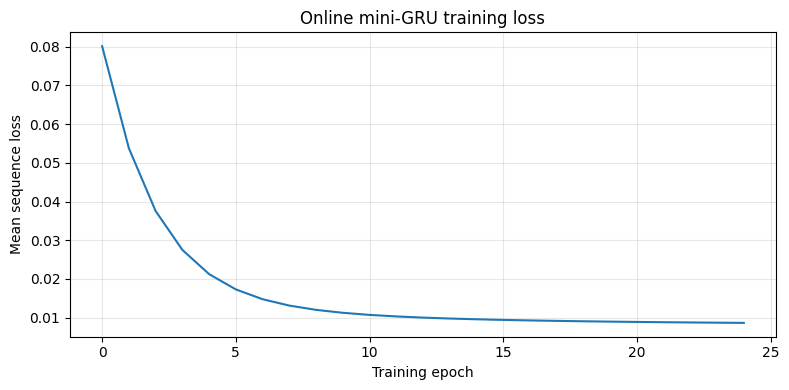

In [3]:
initial_loss = evaluate()
training_losses = brainstate.transform.for_loop(
    train_epoch, jnp.arange(25)
)
final_loss = evaluate()

print(f"initial loss: {float(initial_loss):.4f}")
print(f"final loss: {float(final_loss):.4f}")

with plt.style.context("default"), plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
}):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(training_losses)
    ax.set(xlabel="Training epoch", ylabel="Mean sequence loss")
    ax.set_title("Online mini-GRU training loss")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
plt.show()

With the fixed seed, the final loss should be lower than the initial loss. The example deliberately resets both recurrent and eligibility state before each sequence; otherwise the two loss values would not describe the same initial condition.

## What happened

`braintrace.compile` discovers which MiniGRU parameters reach recurrent hidden state through ETP primitives. `learner.etrace_grad` then drives the whole sequence: it takes the per-step online gradient at each step, carries the accumulator across time, and applies the reduction — `'mean'` divides by the number of steps. `learner.etrace_evolve` is the same drive without a loss, used by `evaluate` to advance hidden state and eligibility traces and return the outputs. `brainstate.transform.for_loop` performs the repeated epoch updates without repeatedly dispatching model calls from Python.

## Next steps

- [Core Concepts](concepts.ipynb) explains how ETP primitives select trainable pathways.
- [RNN Online Learning](../tutorials/rnn_online_learning.ipynb) develops the rate-RNN workflow.
- [SNN Online Learning](../tutorials/snn_online_learning.ipynb) develops the spiking-network workflow.